# Monitoramento PBA 2026: Geolocalização de Turmas e Coordenadores
Este notebook processa dados educacionais para gerar um mapa interativo do estado de Sergipe, permitindo a visualização espacial de turmas, DREs e áreas de atuação de coordenadores.

In [ ]:
# Importando bibliotecas de datasets
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import patheffects
import unicodedata
import plotly.express as px
import plotly.graph_objects as go
import json
import requests

# Importando datasets
df_turmas = pd.read_excel('data_files/municipios_turmas.xlsx')
df_alfabetizacao = pd.read_excel('data_files/dados de municipios e turmas.xlsx')

# 3. CARREGAR MAPA
se_geo = gpd.read_file('data_files/SE_Municipios_2024/SE_Municipios_2024.shp')


In [56]:
# 1. FUNÇÃO PARA NORMALIZAR NOMES E ABREVIAR
def normalizar(txt):
    if pd.isna(txt): return ""
    # Remove acentos e padroniza para maiúsculas
    n = "".join(c for c in unicodedata.normalize('NFD', str(txt).upper()) 
                if unicodedata.category(c) != 'Mn').replace(".", "").strip()
    # Abrevia Nossa Senhora para NS
    return n.replace("NOSSA SENHORA", "NS")

# Aplicar normalização e abreviação
df_turmas['DRE'] = df_turmas['DRE'].astype(str)
df_turmas['Municípios'] = df_turmas['Municípios'].apply(normalizar)
df_alfabetizacao['Município'] = df_alfabetizacao['Município'].apply(normalizar)

# Correções específicas de merge
df_mapa_turmas = df_turmas.groupby('Municípios').agg({
    'DRE': 'first',
    'Número de Turmas': 'sum', 
    'Índice de coordenador': lambda x: ', '.join(map(str, sorted(x.unique().astype(str)))),
    'Nome do Coordenador': lambda x: '<br>   - '.join(x.unique())
}).reset_index()
df_mapa_turmas['NOME_BUSCA'] = df_mapa_turmas['Municípios'].apply(normalizar)

df_mapa_alfabetizacao = df_alfabetizacao[['Município', 'Analfabetismo a cada 100 pessoas']].copy()
df_mapa_alfabetizacao['NOME_BUSCA'] = df_mapa_alfabetizacao['Município'].apply(normalizar)

# Aplicamos a mesma abreviação nos nomes vindos do IBGE para o merge funcionar
se_geo['NOME_BUSCA'] = se_geo['NM_MUN'].apply(normalizar)

# 4. CRUZAR DADOS
municipios_finais = se_geo.merge(df_mapa_turmas, on='NOME_BUSCA', how='left')
municipios_finais = municipios_finais.merge(df_mapa_alfabetizacao, on='NOME_BUSCA', how='left')

# Garantir projeção correta para o mapa (WGS84)
if se_geo.crs != "EPSG:4326":
    se_geo = se_geo.to_crs(epsg=4326)

geojson_se = json.loads(se_geo.to_json())

# Calcular centroides exatos para os labels fixos
centroides = {}
for idx, row in se_geo.iterrows():
    centro = row.geometry.centroid
    centroides[row['NOME_BUSCA']] = (centro.y, centro.x)


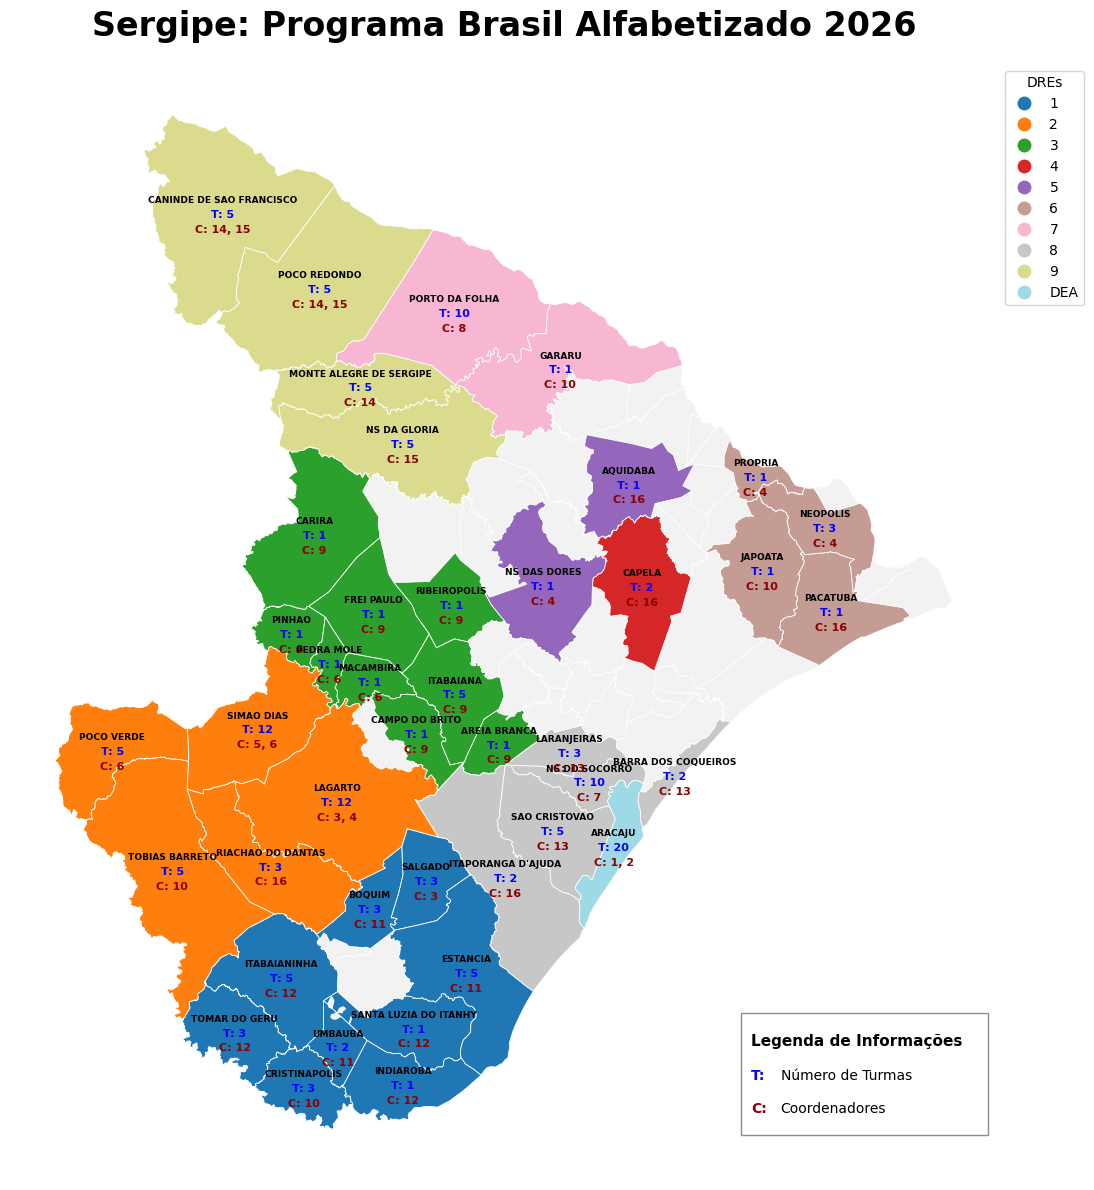

In [57]:
# 5. CONFIGURAR A VISUALIZAÇÃO
fig, ax = plt.subplots(figsize=(16, 12))

# Desenhar fundo
se_geo.plot(ax=ax, color='#f2f2f2', edgecolor='white', linewidth=0.6)

# Desenhar municípios com dados
municipios_com_dados = municipios_finais.dropna(subset=['DRE'])
municipios_com_dados.plot(
    column='DRE', categorical=True, legend=True, ax=ax, cmap='tab20', 
    edgecolor='white', linewidth=0.6,
    legend_kwds={'title': "DREs", 'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
)

# --- LEGENDA DE INFORMAÇÕES (COM TAMANHO AJUSTADO E ALINHAMENTO) ---
# Usamos um retângulo que se adapta melhor ao texto
# x_start, y_start, largura, altura
rect = plt.Rectangle((0.74, 0.04), 0.25, 0.11, transform=ax.transAxes, 
                      facecolor='white', edgecolor='gray', alpha=0.9, zorder=3)
ax.add_patch(rect)

ax.text(0.75, 0.12, "Legenda de Informações", transform=ax.transAxes, 
        fontsize=11, weight='bold', zorder=4)

# Linha T
ax.text(0.75, 0.09, "T:", transform=ax.transAxes, color='blue', 
        fontsize=10, weight='bold', zorder=4)
ax.text(0.78, 0.09, "Número de Turmas", transform=ax.transAxes, 
        color='black', fontsize=10, zorder=4)

# Linha C
ax.text(0.75, 0.06, "C:", transform=ax.transAxes, color='darkred', 
        fontsize=10, weight='bold', zorder=4)
ax.text(0.78, 0.06, "Coordenadores", transform=ax.transAxes, 
        color='black', fontsize=10, zorder=4)

# 6. ADICIONAR LABELS NOS MUNICÍPIOS      
for idx, row in municipios_com_dados.iterrows():
    nome_busca = row['NOME_BUSCA']
    nome_exibicao = row['Município']
    
    if nome_busca in centroides:
        y, x = centroides[nome_busca]
        
        # Abreviação do nome para o label do mapa
        nome_exibir = row['NM_MUN'].upper().replace("NOSSA SENHORA", "NS")
        
        ax.text(x, y + 0.015, nome_exibicao, fontsize=6.5, ha='center', va='bottom', weight='bold')
        ax.text(x, y - 0.005, f"T: {int(row['Número de Turmas'])}", 
                color='blue', fontsize=8, ha='center', va='center', weight='bold')
        ax.text(x, y - 0.025, f"C: {row['Índice de coordenador']}", 
                color='darkred', fontsize=8, ha='center', va='top', weight='bold')

# FINALIZAÇÃO
ax.set_title("Sergipe: Programa Brasil Alfabetizado 2026", fontsize=24, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('data_files/mapa_sergipe_pba_2026.png', dpi=300)
plt.show()


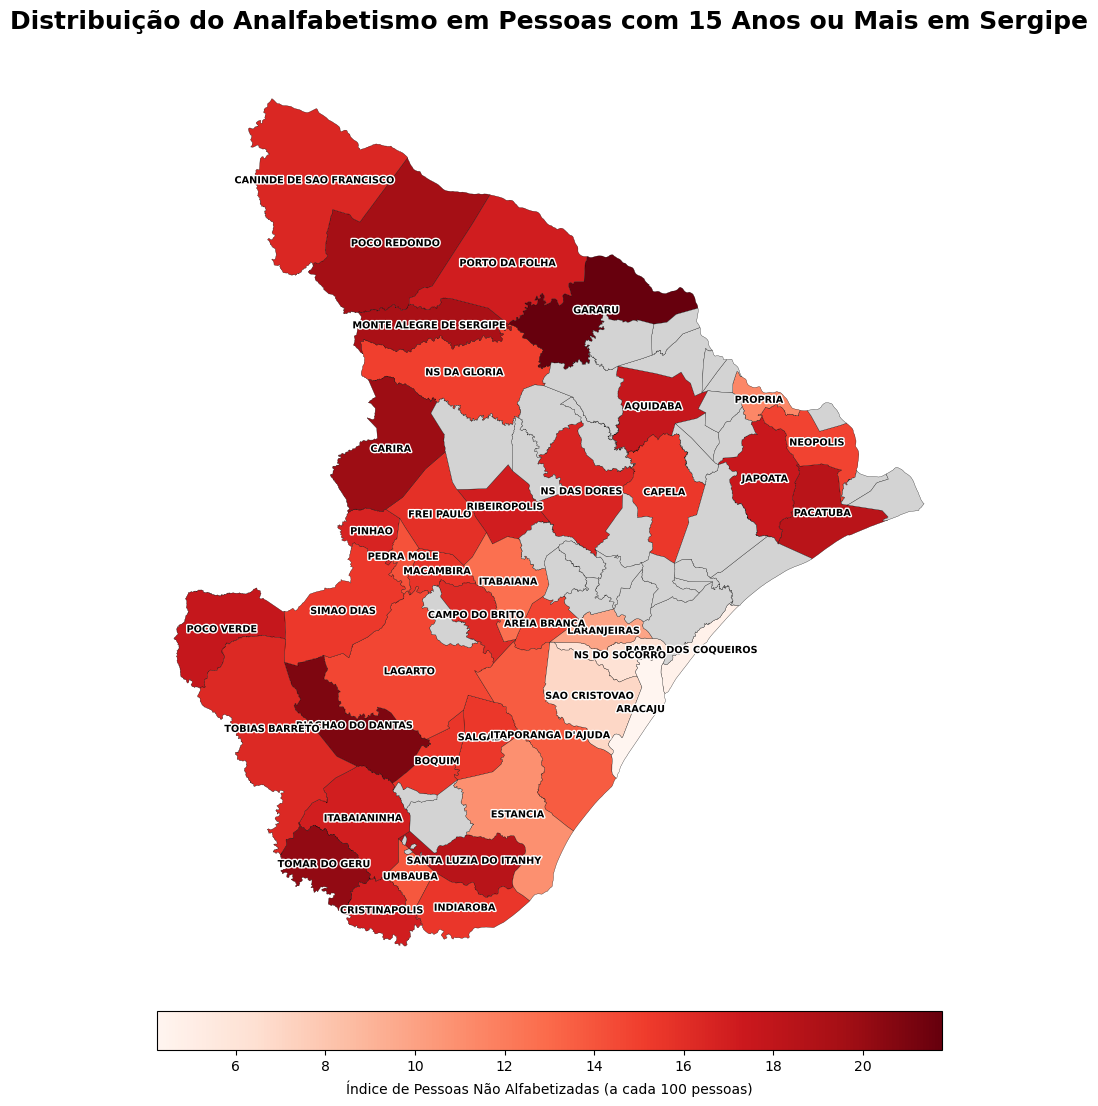

In [58]:
# 4. Configurar a plotagem
fig, ax = plt.subplots(figsize=(16, 12))

# Municípios sem dados (os que não estavam nos seus 42) ficam em cinza claro
municipios_finais.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.5)

# Plotar o heatmap com os seus dados
municipios_finais.plot(
    column='Analfabetismo a cada 100 pessoas', 
    ax=ax, 
    legend=True,
    cmap='Reds', # Tons de vermelho (ou 'YlOrRd' para Amarelo/Laranja/Vermelho)
    edgecolor='black', 
    linewidth=0.2,
    legend_kwds={
        'label': "Índice de Pessoas Não Alfabetizadas (a cada 100 pessoas)",
        'orientation': "horizontal",
        'pad': 0.02,
        'shrink': 0.5
    },
    missing_kwds={'color': 'lightgrey'} # Municípios sem dados
)

# 4. Adicionar os nomes usando o seu dicionário de centroides
# Iteramos apenas pelos municípios que estão no seu DataFrame de alfabetização
for _, row in df_mapa_alfabetizacao.iterrows():
    nome_busca = row['NOME_BUSCA']
    nome_exibicao = row['Município']
    
    if nome_busca in centroides:
        lat, lon = centroides[nome_busca]
        
        # Plotamos o texto usando (lon, lat) que corresponde a (x, y)
        txt = ax.text(
            lon, lat, 
            nome_exibicao,
            fontsize=7,
            ha='center',
            va='center',
            fontweight='bold',
            color='black',
            clip_on=True
        )
        
        # Adiciona um contorno branco para garantir legibilidade sobre cores escuras
        txt.set_path_effects([
            patheffects.withStroke(linewidth=2, foreground="white")
        ])

# 5. Finalização
ax.set_title('Distribuição do Analfabetismo em Pessoas com 15 Anos ou Mais em Sergipe', fontsize=18, fontweight='bold', pad=20)
ax.axis('off')
plt.savefig('data_files/mapa_analfabetismo_ibge_2022.png', dpi=300)

plt.tight_layout()
plt.show()


In [59]:
# 5. CRIAR O MAPA
fig = go.Figure()

# --- TRACE 0: VISÃO POR DRE ---
fig.add_trace(go.Choroplethmap(
    geojson=geojson_se,
    locations=df_mapa['Municípios'],
    featureidkey="properties.NOME_BUSCA",
    z=pd.Categorical(df_mapa['DRE']).codes, 
    colorscale="Viridis",
    hoverinfo="text",
    text=(df_mapa['Municípios'] + 
          "<br><b>DRE:</b> " + df_mapa['DRE'] + 
          "<br><b>Total de Turmas:</b> " + df_mapa['Número de Turmas'].astype(str) +
          "<br><b>Coordenadores ativos:</b><br>   - " + df_mapa['Nome do Coordenador']),
    marker_opacity=0.7,
    name="Visão DRE",
    showscale=False
))

# --- TRACES PARA CADA COORDENADOR ---
coordenadores = sorted(df_turmas['Nome do Coordenador'].unique())
for coord in coordenadores:
    # Filtra apenas os dados deste coordenador
    df_coord = df_turmas[df_turmas['Nome do Coordenador'] == coord].copy()
    df_coord['lat'] = df_coord['Municípios'].map(lambda x: centroides.get(x, (0,0))[0])
    df_coord['lon'] = df_coord['Municípios'].map(lambda x: centroides.get(x, (0,0))[1])
    
    # Trace 1: O polígono colorido (vermelho) com o hover específico
    fig.add_trace(go.Choroplethmap(
        geojson=geojson_se,
        locations=df_coord['Municípios'],
        featureidkey="properties.NOME_BUSCA",
        z=[1] * len(df_coord),
        colorscale=[[0, 'red'], [1, 'red']],
        marker_opacity=0.6,
        visible=False,
        showscale=False,
        # AQUI: Ativamos o hover para mostrar apenas as turmas deste coordenador
        hoverinfo="text",
        text=(df_coord['Municípios'] + 
              "<br><b>Coordenador:</b> " + coord +
              "<br><b>Turmas neste município:</b> " + df_coord['Número de Turmas'].astype(str))
    ))
    
    # Trace 2: O label fixo (nome do município + turmas) no centro
    fig.add_trace(go.Scattermap(
        lat=df_coord['lat'],
        lon=df_coord['lon'],
        mode='text',
        text=df_coord['Municípios'] + "<br>T: " + df_coord['Número de Turmas'].astype(str),
        textfont=dict(size=11, color="black", family="Arial Black"),
        visible=False,
        hoverinfo="skip" # O hover do polígono acima já resolve, este pode ser ignorado
    ))

# 6. CONFIGURAR MENU E LAYOUT
num_coords = len(coordenadores)
buttons = [dict(
    method="update",
    label="Ver por DRE",
    args=[{"visible": [True] + [False] * (num_coords * 2)}, {"title": "Sergipe: Divisão por DRE"}]
)]

for i in range(num_coords):
    vis = [False] * (1 + num_coords * 2)
    vis[1 + (i * 2)] = True     # Ativa polígono do coordenador
    vis[1 + (i * 2) + 1] = True # Ativa label fixo
    buttons.append(dict(
        method="update",
        label=f"Coord: {coordenadores[i]}",
        args=[{"visible": vis}, {"title": f"Municípios de {coordenadores[i]}"}]
    ))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, direction="down", x=0.01, xanchor="left", y=1.12, yanchor="top")],
    map_style="open-street-map",
    # Ajuste de zoom para Sergipe aparecer centralizado
    map_zoom=8.2, 
    map_center={"lat": -10.60, "lon": -37.40},
    margin={"r":0,"t":50,"l":0,"b":0},
)

# Salva o arquivo final
fig.write_html("data_files/mapa_interativo_pba.html")
print("Mapa gerado com sucesso! Zoom ajustado e hover detalhado por coordenador configurado.")


Mapa gerado com sucesso! Zoom ajustado e hover detalhado por coordenador configurado.
